## Import Libraries

In [1]:
# import libraries
import torch
import torch.nn.functional as F
from tqdm import tqdm
from torch import nn, optim
from torchvision.utils import save_image
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import numpy as np
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms as transforms
import torchvision

## Loading Dataset

In [2]:
# defining device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# load dataset

dataset = "../assignment/data/k49-train-imgs.npz"
dataset = np.load(dataset)["arr_0"]
dataset = torch.from_numpy(dataset)
dataset = dataset.float()/ 255

dataset_y = "../assignment/data/k49-train-labels.npz"
dataset_y = np.load(dataset_y)["arr_0"]
dataset_y = torch.from_numpy(dataset_y).long()

dataset_test = "../assignment/data/k49-test-imgs.npz"
dataset_test = np.load(dataset_test)["arr_0"]
dataset_test = torch.from_numpy(dataset_test)
dataset_test = dataset_test.float()/ 255

dataset_y_test = "../assignment/data/k49-test-labels.npz"
dataset_y_test = np.load(dataset_y_test)["arr_0"]
dataset_y_test = torch.from_numpy(dataset_y_test).long()

dataset = np.concatenate((dataset, dataset_test))

dataset_y = np.concatenate((dataset_y, dataset_y_test))



## Preprocessing

In [3]:
# definining variables to store the data required for labeling process
from collections import defaultdict
# stores indexes where classes are stored
class_index = defaultdict(lambda: [])
# stores the data located at those indexes for given class
class_data = defaultdict(lambda: [])
# store foreground pixel sum for each data point for given class
class_foreground = defaultdict(lambda: [])
# stores median for each class
class_median = defaultdict(int)
# stores label for each class
class_label = defaultdict(lambda: [])


In [4]:
# add get indexes of data point for each class
for i, j in enumerate(dataset_y):
    class_index[str(j.item())].append(i)
# get data points for each class
for i in range(0,49):
    class_data[str(i)] = dataset[class_index[str(i)]]
FOREGROUND = 0

# get foreground pixel sum for each class
for i in range(0,49):

    for j in class_data[str(i)]:
        
        class_foreground[str(i)].append((j > FOREGROUND).sum())
# get class median
for i in range(0,49):
    class_median[str(i)] = np.median(class_foreground[str(i)])
# append 1 for thick and 0 for thin
for i in range(0,49):
    for j in class_foreground[str(i)]:
        (class_label[str(i)].append(1) if j > class_median[str(i)] else class_label[str(i)].append(0))
# combining data set of all the class 
x = class_data["0"]
y = np.zeros((x.shape[0]))
l = class_label["0"]
for i in range(1,49):
    x = np.concatenate((x, class_data[str(i)]))
    y = np.concatenate((y, np.full(class_data[str(i)].shape[0], i)))
    l = np.concatenate((l, class_label[str(i)]))

data_x = torch.from_numpy(x).to(DEVICE)

data_y = torch.from_numpy(y).to(DEVICE)

label = torch.from_numpy(l).to(DEVICE)
    

## Model 1 : CVAE
### Training Parameter

In [22]:
# defining configration of our mdoel
INPUT_DIMENSION = 784 # 28*28
HIDDEN_DIMNSION = 300
Z_DIMENSION = 40
NUM_OF_EPOCHS = 50
BATCH_SIZE = 25
LR_RATE = 3e-4
LABEL_NUM = 49
CLASS_NUM = 2
NUM_CLASSES = 49
SEED = 150

### Model Defining

In [17]:
# define class foe conditional variational autoencoder
class CVAE(nn.Module):
    def __init__(self, input_dim, c1_dim = 49, c2_dim = 2 ,h_dim = 200, z_dim = 20):
        super().__init__()

        # defining layers of encoder module
        self.img_2hid = nn.Linear(input_dim + c1_dim + c2_dim, h_dim)
        self.hid_2mu = nn.Linear(h_dim, z_dim)
        self.hid_2sigma = nn.Linear(h_dim, z_dim)

        # defining layers of decoder module
        self.z_2hid = nn.Linear(z_dim + c1_dim + c2_dim, h_dim)
        self.hid_2img = nn.Linear(h_dim, input_dim)

        # relu layer
        self.relu = nn.ReLU()

    # defining encoder module also known as q_phi(z | x)
    def encode(self, x, c1, c2):
        # concatnate x with labels
        x = torch.cat((x, c1, c2), dim = 1)
        # converting images to hidden layer
        h = self.relu(self.img_2hid(x))
        # generating mu and sigma for distribution
        mu, sigma = self.hid_2mu(h), self.hid_2sigma(h) 
        # return the mu and sigma
        return mu, sigma

    # defining decoder module also known as p_theta(x | z)
    def decode(self, z, c1, c2):
        # concatnate x with labels
        z = torch.cat((z, c1, c2), dim = 1)
        # convert data from z layer to hidden layer
        h = self.relu(self.z_2hid(z))
        # convert from hidden layer to image layer
        return torch.sigmoid(self.hid_2img(h))
    
    # define forward pass that uses both encoder and decoder model to generate images

    def forward(self, x, c1, c2):
        # concatnate x with class and style label

        # obtain mean and sigma of distribution
        mu, sigma = self.encode(x, c1, c2)

        # generate random values of same shape as sigma or mean aka z layer from standard normal distribution
        epsilon = torch.randn_like(sigma)

        # convert it to distribution that encoder module learned
        z_reparametized = mu + sigma*epsilon

        # decode it to generate images
        x_reconstructed = self.decode(z_reparametized, c1, c2)

        return x_reconstructed, mu, sigma


In [20]:
# train test split
data_x_train, data_x_test, data_y_train, data_y_test, label_train, label_test = train_test_split(
    data_x, data_y, label, test_size=0.2, random_state=50
)

# Create DataLoader for training and testing sets
train_loader = DataLoader(TensorDataset(data_x_train, data_y_train, label_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(data_x_test, data_y_test, label_test), batch_size=BATCH_SIZE, shuffle=True)

In [23]:
# create instance of model
model = CVAE(INPUT_DIMENSION, LABEL_NUM, CLASS_NUM, HIDDEN_DIMNSION, Z_DIMENSION).to(DEVICE)

# load optimiser
optimizer = optim.Adam(model.parameters(), lr = LR_RATE)

# define loss function
loss_fn = nn.BCELoss(reduction="sum")

### Training loop for CVAE


In [ ]:
# setting seed for training to fix starting point
torch.manual_seed(SEED)
# array to stor loss
epoch_loss_track = []

for epoch in range(NUM_OF_EPOCHS):
    
    loop = tqdm(enumerate(train_loader))

    epoch_loss = 0.0

    for i,(x,class_1, class_2) in loop:
        # reshape the data 
        x = x.to(DEVICE).view(x.shape[0], INPUT_DIMENSION)
        # one hot encoding for y
        class_1 = F.one_hot(class_1.long(), 49).float().to(DEVICE)
        # one hot encoding for label
        class_2 = F.one_hot(class_2.long(), 2).float().to(DEVICE)
        
        # forward pass
        x_reconstructed, mu, sigma = model(x,class_1, class_2)

        # regular loss
        reconstructed_loss = loss_fn(x_reconstructed, x)

        # KL divergence loss
        kl_div = -( torch.sum( 1 + torch.log(sigma.pow(2)) - mu.pow(2) - sigma.pow(2)) )

        # total loss
        loss = reconstructed_loss + kl_div

        # backpropgation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loop.set_postfix(loss = loss.item())

        epoch_loss += loss

    # saving loss for graph
    epoch_loss = epoch_loss / len(train_loader)
    epoch_loss_track.append(epoch_loss.item())
    

8670it [00:39, 217.72it/s, loss=1.08e+3]
8670it [00:38, 224.63it/s, loss=1.05e+3]
8670it [00:40, 213.92it/s, loss=703]    
8670it [00:39, 218.66it/s, loss=935]    
8670it [00:37, 228.87it/s, loss=866]    
8670it [00:37, 232.69it/s, loss=803]    
8670it [00:37, 232.30it/s, loss=769]    
8670it [00:37, 232.37it/s, loss=811]    
8670it [00:37, 232.89it/s, loss=857]    
8670it [00:37, 233.02it/s, loss=848]    
8670it [00:37, 228.75it/s, loss=982]    
8670it [00:37, 229.52it/s, loss=892]    
8670it [00:36, 234.56it/s, loss=669]    
8670it [00:37, 228.19it/s, loss=756]    
8670it [00:37, 232.26it/s, loss=990]    
8670it [00:37, 229.87it/s, loss=781]    
8670it [00:37, 230.82it/s, loss=597]    
8670it [00:37, 231.51it/s, loss=837]    
8670it [00:37, 233.52it/s, loss=758]    
8670it [00:36, 234.75it/s, loss=846]    
8670it [00:36, 236.36it/s, loss=750]    
8670it [00:36, 237.28it/s, loss=789]    
8670it [00:37, 233.88it/s, loss=1.08e+3]
8670it [00:37, 233.16it/s, loss=925]    
8670it [00:38, 2

Text(0, 0.5, 'loss')

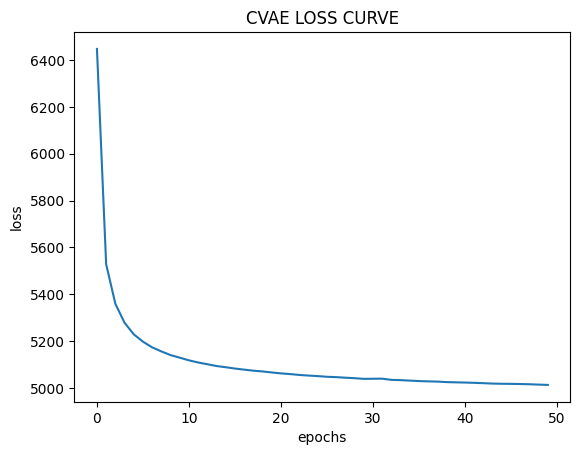

In [ ]:
# saving model at the end of training
torch.save(model.state_dict(), "CVAE_MODEL_FINALE_CHECKPOINT")

# saving CVAE model loss values
np.save("CVAE_LOSS", np.array(epoch_loss_track))

# plot loss curve at the end of training
plt.plot(epoch_loss_track)
plt.title("CVAE LOSS CURVE")
plt.xlabel("epochs")
plt.ylabel("loss")

In [ ]:
def inference(latter, style, num_examples = 1):
    for (x, y, l) in zip(data_x, data_y, label):
        if ((float(y.item()) == float(latter)) & (float(l.item()) == float(style))):
            x_inference, y_inference, l_inference = x,y,l
            print(y_inference, l_inference)
            break
    
    with torch.no_grad():
        print(x_inference.shape, y_inference.shape, l_inference.shape)
        c1 = F.one_hot(y_inference.long(), 49).float().to(DEVICE)
        c2 = F.one_hot(l_inference.long(), 2).float().to(DEVICE)
        print(c1.shape, c2.shape)

        mu, sigma = model.to(DEVICE).encode(x_inference.view(1, 784).to(DEVICE), c1.unsqueeze(0).to(DEVICE), c2.unsqueeze(0).to(DEVICE))

        for example in range(num_examples):
            epsilon = torch.randn_like(sigma)
            z = mu + sigma*epsilon
            out = model.decode(z, c1.unsqueeze(0), c2.unsqueeze(0))
            out = out.view(-1, 1, 28, 28)
            save_image(out, f"Generated_{latter}_class{style}_ex{example}.png")
                        
        

In [ ]:
for i in range(0,49):
    for j in range(0,2):
        inference(i,j,1)

tensor(0., device='cuda:0', dtype=torch.float64) tensor(0, device='cuda:0', dtype=torch.int32)
torch.Size([28, 28]) torch.Size([]) torch.Size([])
torch.Size([49]) torch.Size([2])
tensor(0., device='cuda:0', dtype=torch.float64) tensor(1, device='cuda:0', dtype=torch.int32)
torch.Size([28, 28]) torch.Size([]) torch.Size([])
torch.Size([49]) torch.Size([2])
tensor(1., device='cuda:0', dtype=torch.float64) tensor(0, device='cuda:0', dtype=torch.int32)
torch.Size([28, 28]) torch.Size([]) torch.Size([])
torch.Size([49]) torch.Size([2])
tensor(1., device='cuda:0', dtype=torch.float64) tensor(1, device='cuda:0', dtype=torch.int32)
torch.Size([28, 28]) torch.Size([]) torch.Size([])
torch.Size([49]) torch.Size([2])
tensor(2., device='cuda:0', dtype=torch.float64) tensor(0, device='cuda:0', dtype=torch.int32)
torch.Size([28, 28]) torch.Size([]) torch.Size([])
torch.Size([49]) torch.Size([2])
tensor(2., device='cuda:0', dtype=torch.float64) tensor(1, device='cuda:0', dtype=torch.int32)
torch.Size

In [26]:
checkpoint = torch.load('CVAE_MODEL_FINALE_CHECKPOINT')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [ ]:
def inference(latter, style, num_examples = 1):
    for (x, y, l) in zip(data_x, data_y, label):
        if ((float(y.item()) == float(latter)) & (float(l.item()) == float(style))):
            x_inference, y_inference, l_inference = x,y,l
            print(y_inference, l_inference)
            break
    
    with torch.no_grad():
        print(x_inference.shape, y_inference.shape, l_inference.shape)
        c1 = F.one_hot(y_inference.long(), 49).float().to(DEVICE)
        c2 = F.one_hot(l_inference.long(), 2).float().to(DEVICE)
        print(c1.shape, c2.shape)
        mu, sigma = model.encode(x_inference.view(1, 784), c1.unsqueeze(0), c2.unsqueeze(0))

        for example in range(num_examples):
            epsilon = torch.randn_like(sigma)
            z = mu + sigma*epsilon
            out = model.decode(z, c1.unsqueeze(0), c2.unsqueeze(0))
            out = out.view(-1, 1, 28, 28)
            save_image(out, f"Generated_{latter}_class{style}_ex{example}.png")
                        
        

## Model 2 CGAN

In [5]:
# defining hyperparameters
device = "cuda" if torch.cuda.is_available() else "cpu"
learning_Rate = 1e-4
BATCH_SIZE = 64
IMAGE_SIZE = 64
CHANNELS_IMG = 1
Z_DIMENSION = 100
NUM_EPOCHS = 15
CRITIC_FEATURES = 16
FEATURES_GEN = 16
CRITIC_ITERATIONS = 5
GP_LAMBDA = 10
NUM_CLASSES = 49
NUM_STYLES = 2
GEN_EMBEDDING = 100

In [6]:
dataloader = DataLoader(TensorDataset(data_x*2 - 1, data_y, label), batch_size=BATCH_SIZE, shuffle=True)

In [7]:
class Discriminator(nn.Module):
    def __init__(self, img_channel_num, feature_dimension, num_classes, num_styles, img_size):
        super(Discriminator, self).__init__()
        self.img_size = img_size
        self.disc = nn.Sequential(
            # input will be: N x img_channel_num x 64 x 64
            nn.Conv2d(img_channel_num + 2  , feature_dimension, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            
            # cnn_block(in_channels, out_channels, kernel_size, stride, padding)
            self.cnn_block(feature_dimension, feature_dimension * 2, 4, 2, 1),
            self.cnn_block(feature_dimension * 2, feature_dimension * 4, 4, 2, 1),
            self.cnn_block(feature_dimension * 4, feature_dimension * 8, 4, 2, 1),
            # After all cnn_block img output is 4x4 (Conv2d below makes into 1x1)
            nn.Conv2d(feature_dimension * 8, 1, kernel_size=4, stride=2, padding=0),
        )
        self.embed = nn.Embedding(num_classes, img_size*img_size)
        self.embed2 = nn.Embedding(num_styles, img_size*img_size)

    def cnn_block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias=False,
            ),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x, labels, styles):
        embedding1 = self.embed(labels).view(labels.shape[0], 1, self.img_size, self.img_size)
        embedding2 = self.embed2(styles).view(styles.shape[0], 1, self.img_size, self.img_size)
        x = torch.cat((x, embedding1, embedding2), dim = 1 )
        return self.disc(x)


class Generator(nn.Module):
    def __init__(self, noise_channel, img_channel_num, features_g, num_classes, num_styles,  img_size, embed_size):
        super(Generator, self).__init__()
        self.img_size = img_size
        self.net = nn.Sequential(
            # Input will be: N x noise_channel x 1 x 1
            self.cnn_block(noise_channel + embed_size*2, features_g * 16, 4, 1, 0),  # imgshpae: 4x4
            self.cnn_block(features_g * 16, features_g * 8, 4, 2, 1),  # imgshape: 8x8
            self.cnn_block(features_g * 8, features_g * 4, 4, 2, 1),  # imgshape: 16x16
            self.cnn_block(features_g * 4, features_g * 2, 4, 2, 1),  # imgshape: 32x32
            nn.ConvTranspose2d(
                features_g * 2, img_channel_num, kernel_size=4, stride=2, padding=1
            ),
            # Output will be: N x img_channel_num x 64 x 64
            nn.Tanh(),
        )
        self.embed = nn.Embedding(num_classes, embed_size)
        self.embed2 = nn.Embedding(num_styles, embed_size)

    def cnn_block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x, labels, styles):
        # input will be Num x noise x 1 x 1
        embedding1 = self.embed(labels).unsqueeze(2).unsqueeze(3)
        embedding2 = self.embed2(styles).unsqueeze(2).unsqueeze(3)
        x = torch.cat([x,  embedding1, embedding2], dim = 1)

        return self.net(x)


def initialize_weights(model):
    # weights are assigned based on DCGAN paper
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)


def gradient_penalty(critic, real, fake, labels, styles,  device="cpu"):
    BATCH_SIZE, C, H, W = real.shape
    alpha = torch.rand((BATCH_SIZE, 1, 1, 1)).repeat(1, C, H, W).to(device)
    images_interpolated = real * alpha + fake * (1 - alpha)

    # Calculate image critic score
    mix_scores = critic(images_interpolated, labels, styles)

    # calculate gradient of the scores for images
    gradient = torch.autograd.grad(
        inputs=images_interpolated,
        outputs=mix_scores,
        grad_outputs=torch.ones_like(mix_scores),
        create_graph=True,
        retain_graph=True,
    )[0]
    gradient = gradient.view(gradient.shape[0], -1)
    gradient_norm = gradient.norm(2, dim=1)
    gradient_penalty = torch.mean((gradient_norm - 1) ** 2)
    return gradient_penalty


def save_checkpoint(state, filename="cgan_gp.pth.tar"):
    print("Saving current checkpoint")
    torch.save(state, filename)


def load_checkpoint(checkpoint, gen, disc):
    print("Loading current checkpoint")
    gen.load_state_dict(checkpoint['gen'])
    disc.load_state_dict(checkpoint['disc'])

### Model 2 - Training Loop

In [10]:
gen = Generator(Z_DIMENSION, CHANNELS_IMG, FEATURES_GEN, NUM_CLASSES, NUM_STYLES, IMAGE_SIZE, GEN_EMBEDDING).to(device)
critic = Discriminator(CHANNELS_IMG, CRITIC_FEATURES, NUM_CLASSES, NUM_STYLES, IMAGE_SIZE).to(device)
initialize_weights(gen)
initialize_weights(critic)

# initializate optimizer
opt_gen = optim.Adam(gen.parameters(), lr=learning_Rate, betas=(0.0, 0.9))
opt_critic = optim.Adam(critic.parameters(), lr=learning_Rate, betas=(0.0, 0.9))

# for tensorboard plotting
fixed_noise = torch.randn(32, Z_DIMENSION, 1, 1).to(device)
writer_real = SummaryWriter(f"logs/CWGAN/real")
writer_fake = SummaryWriter(f"logs/CWGAN/fake")
step = 0

gen.train()
critic.train()

Discriminator(
  (disc): Sequential(
    (0): Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Sequential(
      (0): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (3): Sequential(
      (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (4): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (5): Conv2d(128, 1, kernel_size=(4, 4), stride=(2, 2))
  )
  (embed): Embedding(49, 4096

In [11]:
transform = transforms.Compose(
    [
        transforms.ToPILImage(),  # Convert tensor to PIL image
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
    ]
)


In [12]:
for epoch in range(NUM_EPOCHS):
    # Target labels not needed! <3 unsupervised
    for batch_idx, (real, labels, styles) in enumerate(tqdm(dataloader)):
        real = torch.stack([transform(r) for r in real]).to(device)
        labels = labels.to(device).long()
        styles = styles.to(device).long()
        cur_batch_size = real.shape[0]

        # Train Critic: max E[critic(real)] - E[critic(fake)]
        # equivalent to minimizing the negative of that
        for _ in range(CRITIC_ITERATIONS):
            noise = torch.randn(cur_batch_size, Z_DIMENSION, 1, 1).to(device).float()
            fake = gen(noise, labels, styles)
            critic_real = critic(real, labels, styles).reshape(-1)
            critic_fake = critic(fake, labels, styles).reshape(-1)
            gp = gradient_penalty(critic, real, fake, labels, styles, device=device)
            loss_critic = (
                -(torch.mean(critic_real) - torch.mean(critic_fake)) + GP_LAMBDA * gp
            )
            critic.zero_grad()
            loss_critic.backward(retain_graph=True)
            opt_critic.step()

        # Train Generator: max E[critic(gen_fake)] <-> min -E[critic(gen_fake)]
        gen_fake = critic(fake, labels, styles).reshape(-1)
        loss_gen = -torch.mean(gen_fake)
        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        # Print losses occasionally and print to tensorboard
        if batch_idx % 100 == 0 and batch_idx > 0:
            print(
                f"Epoch [{epoch}/{NUM_EPOCHS}] Batch {batch_idx}/{len(dataloader)} \
                  Loss D: {loss_critic:.4f}, loss G: {loss_gen:.4f}"
            )

            with torch.no_grad():
                fake = gen(noise, labels, styles)
                # take out (up to) 32 examples
                real_img_grid = torchvision.utils.make_grid(real[:32], normalize=True)
                fake_img_grid = torchvision.utils.make_grid(fake[:32], normalize=True)

                writer_real.add_image("Real", real_img_grid, global_step=step)
                writer_fake.add_image("Fake", fake_img_grid, global_step=step)

            step += 1

        if epoch % 5 == 0:
            torch.save(gen.state_dict(), f"gen_checkpoint_{epoch}")
            torch.save(critic.state_dict(), f"critic_checkpoint_{epoch}")

  2%|▏         | 100/4233 [00:19<11:54,  5.79it/s]

Epoch [0/15] Batch 100/4233                   Loss D: -42.0960, loss G: 42.4410


  5%|▍         | 201/4233 [00:37<13:40,  4.92it/s]

Epoch [0/15] Batch 200/4233                   Loss D: -35.2015, loss G: 45.1991


  7%|▋         | 301/4233 [00:55<12:56,  5.06it/s]

...

Epoch [7/15] Batch 2100/4233                   Loss D: -2.1375, loss G: -192.3435


 52%|█████▏    | 2201/4233 [05:56<06:36,  5.12it/s]

Epoch [7/15] Batch 2200/4233                   Loss D: -2.0841, loss G: -217.0572


 53%|█████▎    | 2223/4233 [05:59<05:25,  6.18it/s]


KeyboardInterrupt: 

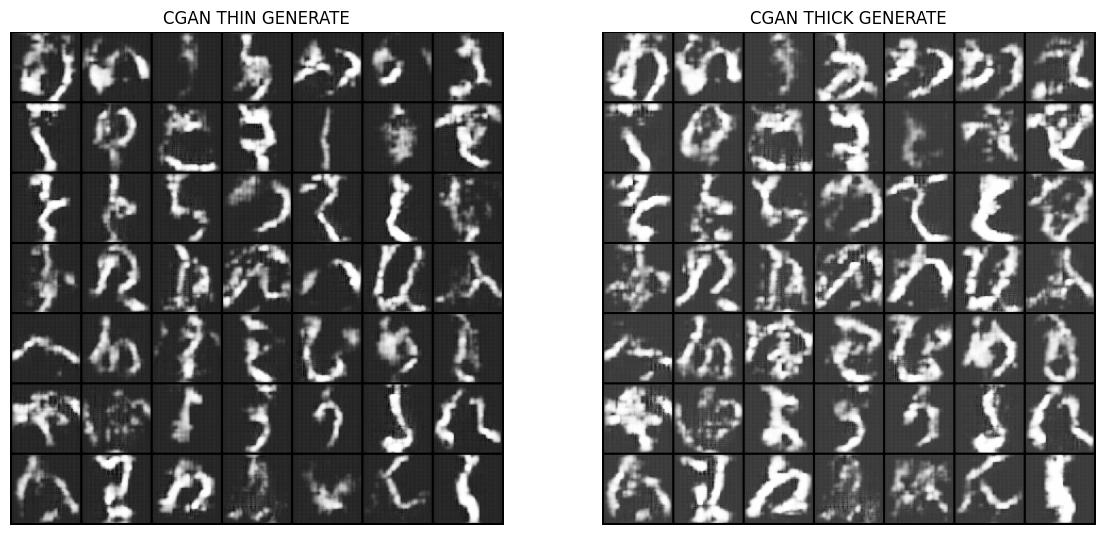

In [15]:
# Seting the model to evaluaation mode
gen.eval()

# Number of clases and stylees
num_classes = 49
num_styles = 2

# Fixed noise foor reproduciebility
fixed_noise = torch.randn(num_classes, Z_DIMENSION, 1, 1).to(DEVICE)

# Function to generate images for a given style
def image_generaor(style):
    # Creating labels andd stylestensor
    labels = torch.arange(num_classes).long().to(DEVICE)
    styles = torch.tensor([style] * num_classes).long().to(DEVICE)
    
    # Generating images
    with torch.no_grad():
        fake_images = gen(fixed_noise, labels, styles)
        
    return fake_images

# Generating images for sthin and thick
thin_image = image_generaor(0)
thick_image = image_generaor(1)

# Convert images to a imggrid
grid_style_0 = torchvision.utils.make_grid(thin_image, nrow=7, normalize=True)
grid_style_1 = torchvision.utils.make_grid(thick_image, nrow=7, normalize=True)

# Ploting the genimages
figure, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(np.transpose(grid_style_0.cpu(), (1, 2, 0)))
axes[0].set_title('CGAN THIN GENERATE')
axes[0].axis('off')

axes[1].imshow(np.transpose(grid_style_1.cpu(), (1, 2, 0)))
axes[1].set_title('CGAN THICK GENERATE')
axes[1].axis('off')

plt.show()